In [1]:
import torch
import torch.nn as nn

# -------------------------------
# 1) Operador de la ecuación de Schrodinger 1D (iría en nn/pde.py)
# -------------------------------
def schrodinger_operator(model, t, x, potential_fn=None, mass=1.0, hbar=1.0):
    """
    Residuos de: i*hbar*psi_t = -(hbar^2/(2m)) * psi_xx + V * psi
    model(t,x) -> [psi_r, psi_i]
    """
    t = t.requires_grad_(True)
    x = x.requires_grad_(True)

    psi = model(torch.cat((t, x), dim=1))
    psi_r = psi[:, 0:1]
    psi_i = psi[:, 1:2]

    # Derivadas temporales
    psi_t_r = torch.autograd.grad(psi_r, t, torch.ones_like(psi_r), create_graph=True)[0]
    psi_t_i = torch.autograd.grad(psi_i, t, torch.ones_like(psi_i), create_graph=True)[0]

    # Derivadas espaciales segunda
    psi_x_r  = torch.autograd.grad(psi_r, x, torch.ones_like(psi_r), create_graph=True)[0]
    psi_x_i  = torch.autograd.grad(psi_i, x, torch.ones_like(psi_i), create_graph=True)[0]
    psi_xx_r = torch.autograd.grad(psi_x_r, x, torch.ones_like(psi_x_r), create_graph=True)[0]
    psi_xx_i = torch.autograd.grad(psi_x_i, x, torch.ones_like(psi_x_i), create_graph=True)[0]

    V = potential_fn(t, x) if potential_fn is not None else torch.zeros_like(psi_r)
    coef = (hbar**2) / (2.0 * mass)

    residual_r = -hbar * psi_t_i + coef * psi_xx_r - V * psi_r
    residual_i =  hbar * psi_t_r + coef * psi_xx_i - V * psi_i

    return psi_r, psi_i, residual_r, residual_i


# -------------------------------
# 2) Modelo "dummy" analítico: onda plana
# -------------------------------
class PlaneWaveModel(nn.Module):
    """
    Produce psi_r, psi_i de una onda plana: exp(i*(k*x - omega*t)).
    omega debe satisfacer: omega = hbar*k^2/(2*m) + V0/hbar si V=V0 (cte).
    """
    def __init__(self, k: float, mass: float = 1.0, hbar: float = 1.0, V0: float = 0.0):
        super().__init__()
        # Guardamos como tensores para que vivan en el mismo device/dtype que las entradas
        self.k   = torch.tensor(float(k))
        self.m   = torch.tensor(float(mass))
        self.h   = torch.tensor(float(hbar))
        self.V0  = torch.tensor(float(V0))
        # Relación de dispersión (analítica)
        self.omega = self.h * (self.k**2) / (2.0 * self.m) + self.V0 / self.h

    def forward(self, tx: torch.Tensor) -> torch.Tensor:
        # tx: (N,2) -> t=col0, x=col1
        t = tx[:, :1]
        x = tx[:, 1:2]

        # Asegurar que k,omega estén en el mismo device/dtype que t/x
        k = self.k.to(t.device, dtype=t.dtype)
        omega = self.omega.to(t.device, dtype=t.dtype)

        phi = k * x - omega * t
        psi_r = torch.cos(phi)
        psi_i = torch.sin(phi)
        return torch.cat([psi_r, psi_i], dim=1)


# -------------------------------
# 3) Potenciales para test
# -------------------------------
def V_zero(t, x):
    return torch.zeros_like(t)

def V_const_factory(V0: float):
    def V_const(t, x):
        return torch.full_like(t, fill_value=V0)
    return V_const


# -------------------------------
# 4) Rutina de prueba
# -------------------------------
@torch.no_grad()
def summary_stats(name, res_r, res_i):
    r = res_r.detach().abs()
    i = res_i.detach().abs()
    print(f"[{name}] MSE_r={res_r.pow(2).mean():.3e} | MSE_i={res_i.pow(2).mean():.3e}  "
          f"| max_r={r.max():.3e}  max_i={i.max():.3e}")

def run_tests(device=None, dtype=torch.float64):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device} | dtype: {dtype}")

    torch.manual_seed(0)

    # Malla de evaluación
    N = 4096
    t = torch.rand(N, 1, device=device, dtype=dtype) * 1.0      # t in [0,1]
    x = (torch.rand(N, 1, device=device, dtype=dtype) - 0.5) * 2.0 * 3.141592653589793  # x in [-pi, pi]

    # --- Caso A: V=0, varios k ---
    for k in [0.5, 1.0, 2.5]:
        model = PlaneWaveModel(k=k, mass=1.0, hbar=1.0, V0=0.0).to(device)
        psi_r, psi_i, rR, rI = schrodinger_operator(model, t, x, potential_fn=V_zero, mass=1.0, hbar=1.0)
        summary_stats(f"V=0  | k={k}", rR, rI)

    # Umbral esperado (float64): ~1e-10 a 1e-12; con float32: ~1e-6 a 1e-7
    # Puedes hacer asserts suaves:
    model = PlaneWaveModel(k=1.234, mass=1.0, hbar=1.0, V0=0.0).to(device)
    _, _, rR, rI = schrodinger_operator(model, t, x, potential_fn=V_zero, mass=1.0, hbar=1.0)
    tol = 1e-9 if dtype == torch.float64 else 5e-6
    assert rR.pow(2).mean().item() < tol and rI.pow(2).mean().item() < tol, "Test V=0 no pasó el umbral."

    # --- Caso B: V = V0 constante (comprobar término de potencial) ---
    for V0 in [0.3, -0.7]:
        k = 1.1
        model = PlaneWaveModel(k=k, mass=1.0, hbar=1.0, V0=V0).to(device)
        V_fn = V_const_factory(V0)
        psi_r, psi_i, rR, rI = schrodinger_operator(model, t, x, potential_fn=V_fn, mass=1.0, hbar=1.0)
        summary_stats(f"V=cte | V0={V0}", rR, rI)

    print("✔️ Todos los tests básicos ejecutados.")

if __name__ == "__main__":
    run_tests()


Device: cpu | dtype: torch.float64
[V=0  | k=0.5] MSE_r=0.000e+00 | MSE_i=0.000e+00  | max_r=0.000e+00  max_i=0.000e+00
[V=0  | k=1.0] MSE_r=0.000e+00 | MSE_i=0.000e+00  | max_r=0.000e+00  max_i=0.000e+00
[V=0  | k=2.5] MSE_r=3.451e-32 | MSE_i=3.213e-32  | max_r=4.441e-16  max_i=4.441e-16
[V=cte | V0=0.3] MSE_r=1.187e-17 | MSE_i=1.087e-17  | max_r=4.768e-09  max_i=4.768e-09
[V=cte | V0=-0.7] MSE_r=1.220e-17 | MSE_i=1.054e-17  | max_r=4.768e-09  max_i=4.768e-09
✔️ Todos los tests básicos ejecutados.


Epoch     1 | loss=2.368e+00 (pde=2.835e-01, bc=5.036e-02, ic=1.017e+00) | 0.6s
Epoch   100 | loss=6.044e-01 (pde=8.270e-02, bc=1.983e-01, ic=1.617e-01) | 26.5s
Epoch   200 | loss=3.168e-01 (pde=2.152e-02, bc=1.740e-01, ic=6.062e-02) | 52.4s
Epoch   300 | loss=1.547e-01 (pde=1.121e-02, bc=7.327e-02, ic=3.511e-02) | 79.5s
Epoch   400 | loss=1.573e-01 (pde=1.476e-02, bc=8.102e-02, ic=3.075e-02) | 105.8s
Epoch   500 | loss=1.279e-01 (pde=4.920e-03, bc=6.651e-02, ic=2.825e-02) | 132.5s
Epoch   600 | loss=1.064e-01 (pde=6.850e-03, bc=5.232e-02, ic=2.360e-02) | 159.8s
Epoch   700 | loss=8.649e-02 (pde=9.786e-03, bc=4.431e-02, ic=1.620e-02) | 187.6s
Epoch   800 | loss=8.225e-02 (pde=1.897e-02, bc=3.742e-02, ic=1.293e-02) | 215.1s
Epoch   900 | loss=6.788e-02 (pde=1.746e-02, bc=3.163e-02, ic=9.397e-03) | 241.7s
Epoch  1000 | loss=4.558e-02 (pde=7.147e-03, bc=2.432e-02, ic=7.055e-03) | 268.2s
Epoch  1100 | loss=3.690e-02 (pde=7.128e-03, bc=1.949e-02, ic=5.142e-03) | 294.8s
Epoch  1200 | loss=2.

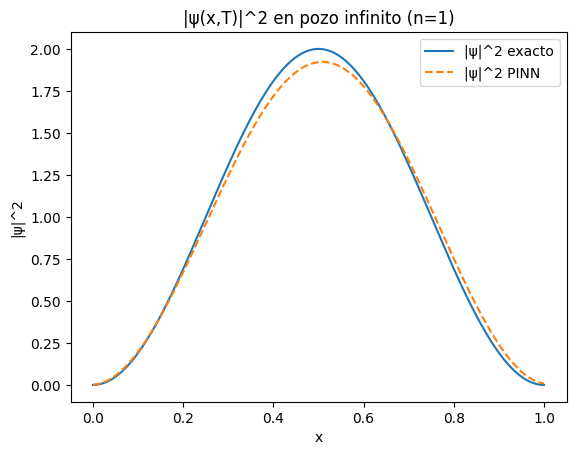

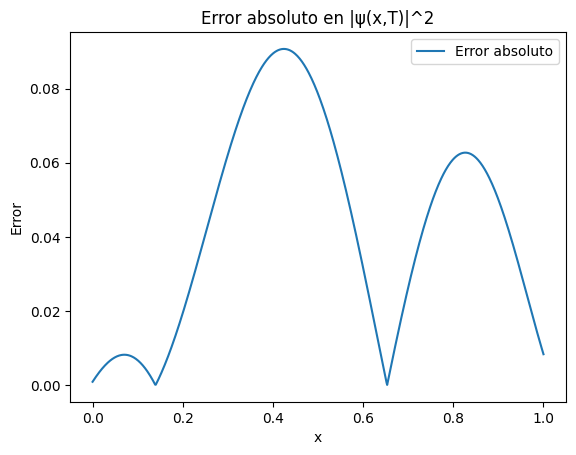

In [2]:
# -*- coding: utf-8 -*-
# PINN para Schrödinger 1D en pozo infinito: estado n=1, BC Dirichlet, IC analítica
# Requisitos: PyTorch, matplotlib

import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ----------------------
# 1) Parámetros físicos y de dominio
# ----------------------
L = 1.0        # dominio espacial [0, L]
T = 0.2        # tiempo final
hbar = 1.0
mass = 1.0
n_level = 1    # nivel del pozo (usaremos n=1)

# ----------------------
# 2) Muestreo y entrenamiento
# ----------------------
N_f = 4000     # collocation (interior)
N_b = 800      # borde (x=0 y x=L)
N_0 = 800      # inicial (t=0)

EPOCHS = 3000   # aumenta si quieres más precisión
LR = 1e-3
PRINT_EVERY = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64  # mejor precisión para EDP de 2º orden
torch.set_default_dtype(DTYPE)
torch.manual_seed(0)

# ----------------------
# 3) Operador de Schrödinger (iría en nn/pde.py)
# ----------------------
def schrodinger_operator(model, t, x, potential_fn=None, mass=1.0, hbar=1.0):
    """
    Residuos de: i*hbar*psi_t = -(hbar^2/(2m)) * psi_xx + V * psi
    model(t,x) -> [psi_r, psi_i]
    """
    t = t.requires_grad_(True)
    x = x.requires_grad_(True)

    psi = model(torch.cat((t, x), dim=1))
    psi_r = psi[:, 0:1]
    psi_i = psi[:, 1:2]

    psi_t_r = torch.autograd.grad(psi_r, t, torch.ones_like(psi_r), create_graph=True)[0]
    psi_t_i = torch.autograd.grad(psi_i, t, torch.ones_like(psi_i), create_graph=True)[0]

    psi_x_r  = torch.autograd.grad(psi_r, x, torch.ones_like(psi_r), create_graph=True)[0]
    psi_x_i  = torch.autograd.grad(psi_i, x, torch.ones_like(psi_i), create_graph=True)[0]
    psi_xx_r = torch.autograd.grad(psi_x_r, x, torch.ones_like(psi_x_r), create_graph=True)[0]
    psi_xx_i = torch.autograd.grad(psi_x_i, x, torch.ones_like(psi_x_i), create_graph=True)[0]

    V = potential_fn(t, x) if potential_fn is not None else torch.zeros_like(psi_r)
    coef = (hbar**2) / (2.0 * mass)

    residual_r = -hbar * psi_t_i + coef * psi_xx_r - V * psi_r
    residual_i =  hbar * psi_t_r + coef * psi_xx_i - V * psi_i

    return psi_r, psi_i, residual_r, residual_i

# ----------------------
# 4) MLP suave para ψ (2 salidas: real e imaginaria)
# ----------------------
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)
        # Inicialización Xavier
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

# ----------------------
# 5) Solución exacta del pozo (para IC y validación)
# ----------------------
def exact_eigenstate(n, t, x, L=1.0, mass=1.0, hbar=1.0):
    pi = torch.tensor(math.pi, device=t.device, dtype=t.dtype)
    k = n * pi / L
    En = (n**2) * (pi**2) * (hbar**2) / (2.0 * mass * (L**2))
    phase = - (En / hbar) * t
    spatial = torch.sqrt(2.0 / torch.tensor(L, device=t.device, dtype=t.dtype)) * torch.sin(k * x)
    psi_r = spatial * torch.cos(phase)
    psi_i = spatial * torch.sin(phase)
    return psi_r, psi_i, En

# ----------------------
# 6) Muestreo de puntos
# ----------------------
def sample_collocation(Nf, Nb, N0, L=1.0, T=0.2, device="cpu", dtype=torch.float64):
    # Interior (PDE)
    t_f = torch.rand(Nf, 1, device=device, dtype=dtype) * T
    x_f = torch.rand(Nf, 1, device=device, dtype=dtype) * L
    # Bordes (x=0 y x=L)
    t_b = torch.rand(Nb, 1, device=device, dtype=dtype) * T
    xb0 = torch.zeros(Nb//2, 1, device=device, dtype=dtype)
    xbL = torch.full((Nb - Nb//2, 1), L, device=device, dtype=dtype)
    x_b = torch.cat([xb0, xbL], dim=0)
    t_b = torch.cat([t_b[:Nb//2], t_b[Nb//2:]], dim=0)
    # Inicial (t=0)
    t_0 = torch.zeros(N0, 1, device=device, dtype=dtype)
    x_0 = torch.rand(N0, 1, device=device, dtype=dtype) * L
    return (t_f, x_f), (t_b, x_b), (t_0, x_0)

# ----------------------
# 7) Entrenamiento
# ----------------------
def train_pinn():
    model = MLP().to(DEVICE).type(DTYPE)
    opt = optim.Adam(model.parameters(), lr=LR)
    mse = nn.MSELoss()

    (t_f, x_f), (t_b, x_b), (t_0, x_0) = sample_collocation(N_f, N_b, N_0, L=L, T=T, device=DEVICE, dtype=DTYPE)
    psi0_r, psi0_i, _ = exact_eigenstate(n_level, t_0, x_0, L=L, mass=mass, hbar=hbar)

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        opt.zero_grad()

        # PDE (interior) con V=0 (pozo interior)
        _, _, rR, rI = schrodinger_operator(model, t_f, x_f, potential_fn=None, mass=mass, hbar=hbar)
        loss_pde = mse(rR, torch.zeros_like(rR)) + mse(rI, torch.zeros_like(rI))

        # BC Dirichlet: ψ=0 en x=0 y x=L
        psi_b = model(torch.cat((t_b, x_b), dim=1))
        loss_bc = mse(psi_b[:, 0:1], torch.zeros_like(psi_b[:, 0:1])) + \
                  mse(psi_b[:, 1:2], torch.zeros_like(psi_b[:, 1:2]))

        # IC: ψ(t=0,x) = sqrt(2/L) sin(pi x/L) (parte imag=0 al inicio)
        psi0 = model(torch.cat((t_0, x_0), dim=1))
        loss_ic = mse(psi0[:, 0:1], psi0_r) + mse(psi0[:, 1:2], psi0_i)

        # Ponderación básica (ajústala si alguna pérdida domina)
        loss = 1.0 * loss_pde + 1.0 * loss_bc + 2.0 * loss_ic

        loss.backward()
        opt.step()

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f"Epoch {epoch:5d} | loss={loss.item():.3e} "
                  f"(pde={loss_pde.item():.3e}, bc={loss_bc.item():.3e}, ic={loss_ic.item():.3e}) | {elapsed:.1f}s")

        # (Opcional) re-muestreo de collocation cada cierto número de épocas:
        # if epoch % 500 == 0:
        #     (t_f, x_f), (t_b, x_b), (t_0, x_0) = sample_collocation(...)

    return model

model = train_pinn()

# ----------------------
# 8) Evaluación y gráficos
# ----------------------
with torch.no_grad():
    t_eval = torch.full((800, 1), T, device=DEVICE, dtype=DTYPE)
    x_eval = torch.linspace(0.0, L, 800, device=DEVICE, dtype=DTYPE).unsqueeze(1)

    psi_pred = model(torch.cat((t_eval, x_eval), dim=1))
    psi_r_pred = psi_pred[:, 0:1]
    psi_i_pred = psi_pred[:, 1:2]
    mod2_pred = (psi_r_pred**2 + psi_i_pred**2).squeeze(1).cpu().numpy()

    psi_r_true, psi_i_true, En = exact_eigenstate(n_level, t_eval, x_eval, L=L, mass=mass, hbar=hbar)
    mod2_true = (psi_r_true**2 + psi_i_true**2).squeeze(1).cpu().numpy()

# Gráfico 1: |psi|^2 en t=T (PINN vs exacto)
plt.figure()
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_true, label="|ψ|^2 exacto")
plt.plot(x_eval.squeeze(1).cpu().numpy(), mod2_pred, "--", label="|ψ|^2 PINN")
plt.title("|ψ(x,T)|^2 en pozo infinito (n=1)")
plt.xlabel("x")
plt.ylabel("|ψ|^2")
plt.legend()
plt.show()

# Gráfico 2: error absoluto en |psi|^2
plt.figure()
abs_err = np.abs(mod2_pred - mod2_true)
plt.plot(x_eval.squeeze(1).cpu().numpy(), abs_err, label="Error absoluto")
plt.title("Error absoluto en |ψ(x,T)|^2")
plt.xlabel("x")
plt.ylabel("Error")
plt.legend()
plt.show()
